In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
import csv
from google.colab import drive
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Colab Notebooks/netflix-prize-data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_titles(path: str):
    titles = []
    with open(path, encoding='latin-1') as f:
        reader = csv.reader(f)
        for row in reader:
            try:
                movie_id = int(row[0])
                year = int(row[1])
                title = ",".join(row[2:])
                titles.append([movie_id, year, title])
            except:
                continue
    return pd.DataFrame(titles, columns=['movie_id', 'year', 'title'])


titles_df = load_titles(base_path+'movie_titles.csv')

In [4]:
def load_ratings(path: str):
    ratings_list = []
    with open(path, 'r') as file:
        movie_id = None
        for line in file:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(',')
                ratings_list.append([int(user_id), movie_id, int(rating), date])

    return pd.DataFrame(ratings_list, columns=['user_id', 'movie_id', 'rating', 'date'])


ratings_df = load_ratings(base_path+'combined_data_1.txt')

In [5]:
df = pd.merge(ratings_df, titles_df, on='movie_id')

## Preview

In [6]:
df.shape

(24053575, 6)

In [7]:
df.head()

,user_id,movie_id,rating,date,year,title
0,1488844,1,3,2005-09-06,2003,Dinosaur Planet
1,822109,1,5,2005-05-13,2003,Dinosaur Planet
2,885013,1,4,2005-10-19,2003,Dinosaur Planet
3,30878,1,4,2005-12-26,2003,Dinosaur Planet
4,823519,1,3,2004-05-03,2003,Dinosaur Planet


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053575 entries, 0 to 24053574
Data columns (total 6 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   movie_id  int64 
 2   rating    int64 
 3   date      object
 4   year      int64 
 5   title     object
dtypes: int64(4), object(2)
memory usage: 1.1+ GB


In [9]:
df.describe()

,user_id,movie_id,rating,year
count,2.405358e+07,2.405358e+07,2.405358e+07,2.405358e+07
mean,1.322286e+06,2.308308e+03,3.599639e+00,1.994406e+03
std,7.645780e+05,1.303901e+03,1.086117e+00,1.259927e+01
min,6.000000e+00,1.000000e+00,1.000000e+00,1.915000e+03
25%,6.609295e+05,1.180000e+03,3.000000e+00,1.991000e+03
50%,1.318594e+06,2.342000e+03,4.000000e+00,1.999000e+03
75%,1.984358e+06,3.433000e+03,4.000000e+00,2.003000e+03
max,2.649429e+06,4.499000e+03,5.000000e+00,2.005000e+03


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
user_id,0
movie_id,0
rating,0
date,0
year,0
title,0


In [12]:
df['date'] = pd.to_datetime(df['date'])

## Analysis

ratings distribution

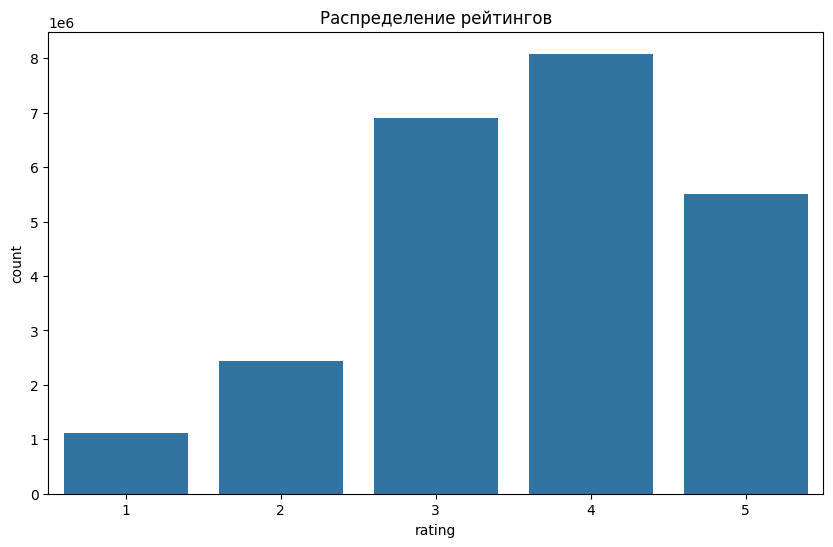

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df)
plt.title('Распределение рейтингов')
plt.show()

In [14]:
rating_stats = df['rating'].value_counts().sort_index()
print(rating_stats)

rating
1    1118166
2    2439037
3    6904098
4    8085708
5    5506566
Name: count, dtype: int64


ratings per user

In [15]:
user_rating_counts = df['user_id'].value_counts()

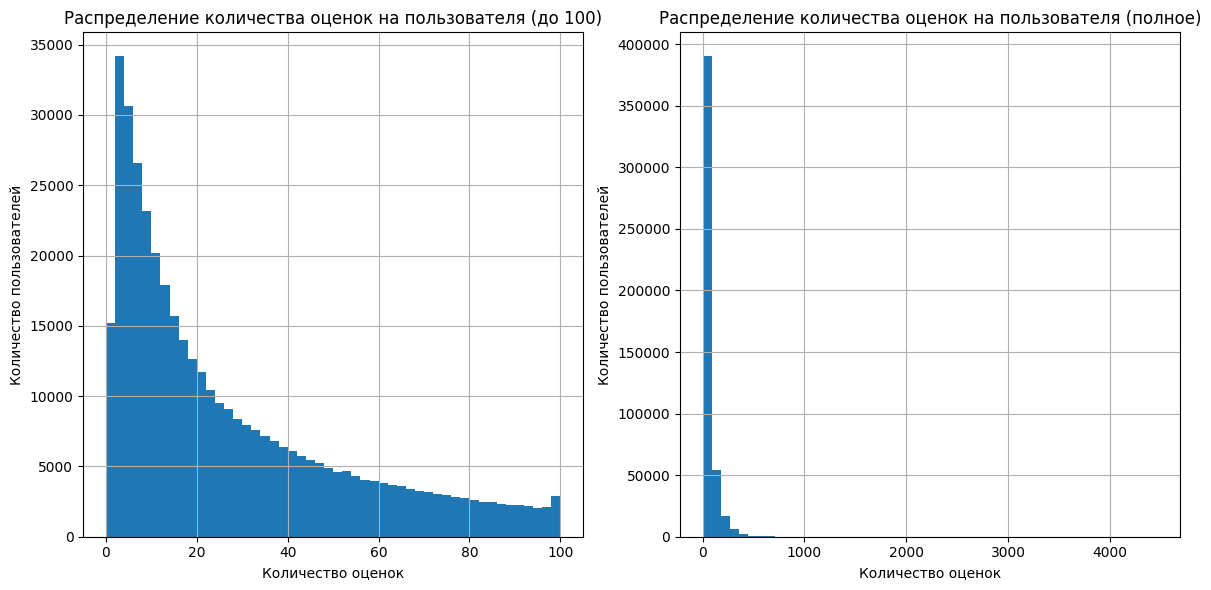

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
user_rating_counts.hist(bins=50, range=(0, 100))
plt.title('Распределение количества оценок на пользователя (до 100)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')

plt.subplot(1, 2, 2)
user_rating_counts.hist(bins=50)
plt.title('Распределение количества оценок на пользователя (полное)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

In [17]:
print("Статистика по количеству оценок на пользователя:")
print(user_rating_counts.describe())

Статистика по количеству оценок на пользователя:
count    470758.000000
mean         51.095414
std          74.403998
min           1.000000
25%           8.000000
50%          24.000000
75%          64.000000
max        4466.000000
Name: count, dtype: float64


number of ratings

In [18]:
movie_rating_counts = df['movie_id'].value_counts()

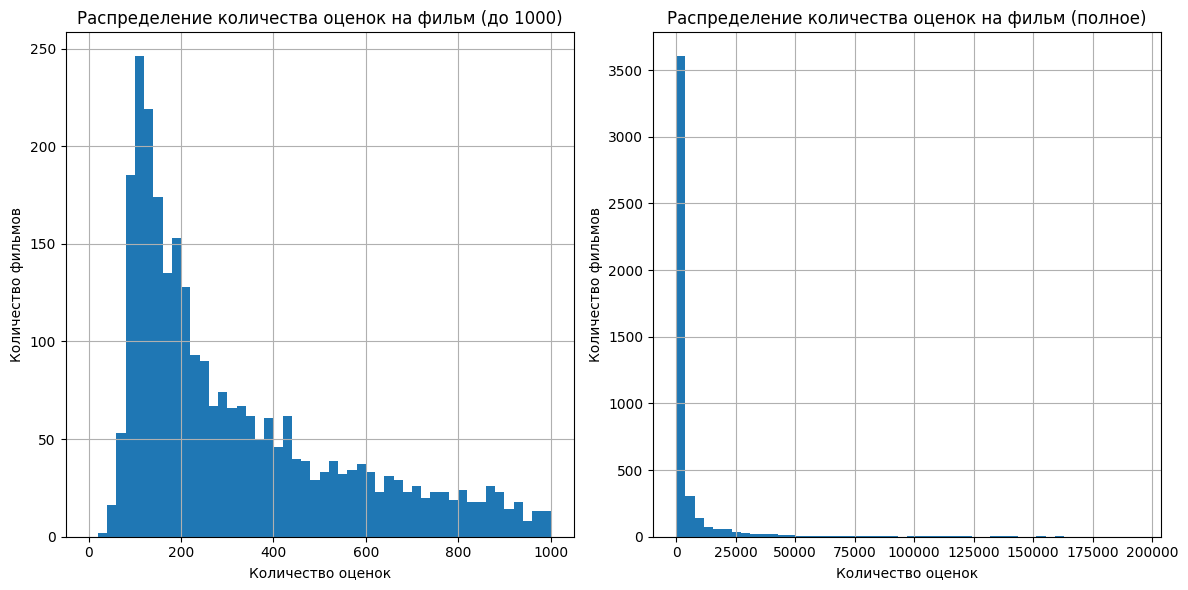

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
movie_rating_counts.hist(bins=50, range=(0, 1000))
plt.title('Распределение количества оценок на фильм (до 1000)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')

plt.subplot(1, 2, 2)
movie_rating_counts.hist(bins=50)
plt.title('Распределение количества оценок на фильм (полное)')
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

In [20]:
print("Статистика по количеству оценок на фильм:")
print(movie_rating_counts.describe())

Статистика по количеству оценок на фильм:
count      4498.000000
mean       5347.615607
std       16177.929470
min          36.000000
25%         192.000000
50%         552.500000
75%        2539.000000
max      193941.000000
Name: count, dtype: float64


activity by date

In [21]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

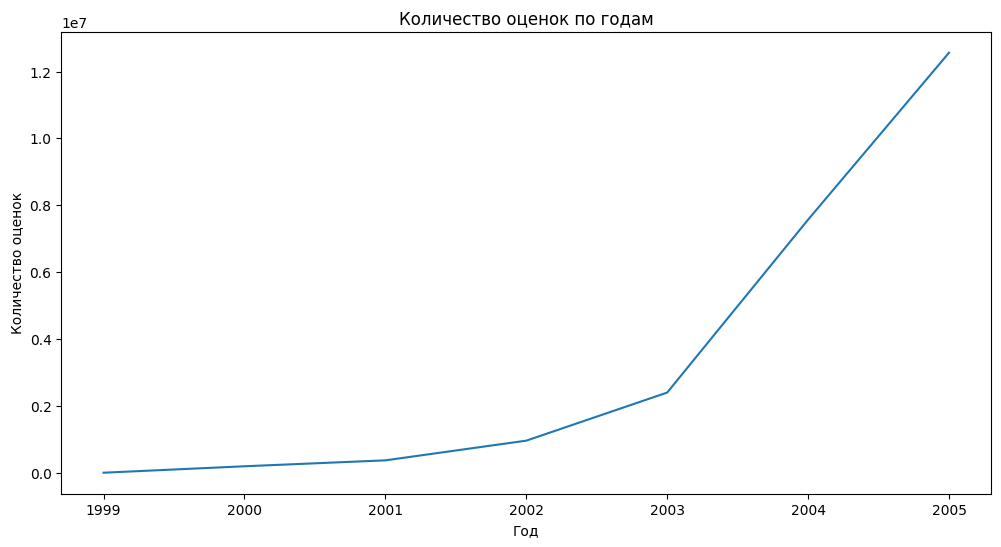

In [22]:
ratings_by_year = df.groupby('year').size()
plt.figure(figsize=(12, 6))
ratings_by_year.plot()
plt.title('Количество оценок по годам')
plt.xlabel('Год')
plt.ylabel('Количество оценок')
plt.show()

movies by year

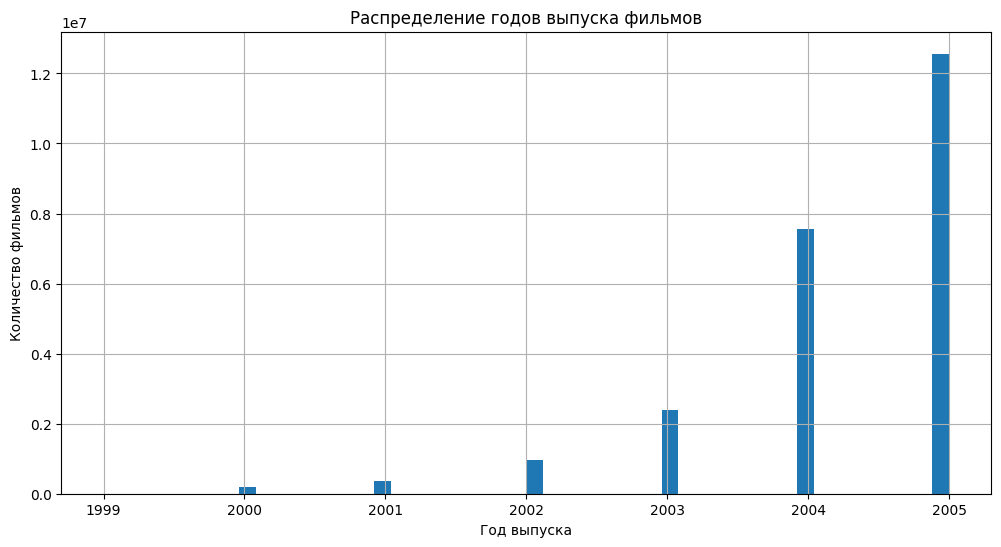

In [23]:
plt.figure(figsize=(12, 6))
df['year'].hist(bins=50)
plt.title('Распределение годов выпуска фильмов')
plt.xlabel('Год выпуска')
plt.ylabel('Количество фильмов')
plt.show()

## Models

data preparation

In [24]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

user_ids = train_data['user_id'].unique()
movie_ids = train_data['movie_id'].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

train_matrix = sparse.csr_matrix((train_data['rating'].values,
                                (train_data['user_id'].map(user_to_idx).values,
                                 train_data['movie_id'].map(movie_to_idx).values)),
                                shape=(len(user_ids), len(movie_ids)))

### MostPop

In [25]:
class MostPop:
    def __init__(self):
        self.popular_items = None

    def fit(self, df):
        self.popular_items = df.groupby('movie_id')['rating'].mean().sort_values(ascending=False)

    def recommend(self, user_id, n=10):
        return self.popular_items.head(n).index.tolist()

In [26]:
mostpop = MostPop()
mostpop.fit(train_data)

### UserKNN

In [27]:
class UserKNN:
    def __init__(self, k=50):
        self.k = k
        self.user_similarity = None
        self.train_matrix = None
        self.user_to_idx = None
        self.idx_to_movie = None

    def fit(self, train_matrix, user_to_idx, movie_ids):
        self.train_matrix = train_matrix
        self.user_to_idx = user_to_idx
        self.idx_to_movie = {idx: movie_id for idx, movie_id in enumerate(movie_ids)}

        self.user_similarity = cosine_similarity(train_matrix)

    def recommend(self, user_id, n=10):
        if user_id not in self.user_to_idx:
            return []

        user_idx = self.user_to_idx[user_id]
        user_ratings = self.train_matrix[user_idx].toarray().flatten()

        similar_users = np.argsort(self.user_similarity[user_idx])[::-1][1:self.k+1]

        item_scores = np.zeros(self.train_matrix.shape[1])

        for sim_user_idx in similar_users:
            similarity = self.user_similarity[user_idx, sim_user_idx]
            sim_user_ratings = self.train_matrix[sim_user_idx].toarray().flatten()
            item_scores += similarity * sim_user_ratings

        rated_items = user_ratings.nonzero()[0]
        item_scores[rated_items] = -np.inf

        top_items = np.argsort(item_scores)[::-1][:n]
        return [self.idx_to_movie[item_idx] for item_idx in top_items]

### ItemKNN

In [28]:
class ItemKNN:
    def __init__(self, k=50):
        self.k = k
        self.item_similarity = None
        self.train_matrix = None
        self.user_to_idx = None
        self.movie_to_idx = None
        self.idx_to_movie = None

    def fit(self, train_matrix, user_to_idx, movie_to_idx, movie_ids):
        self.train_matrix = train_matrix
        self.user_to_idx = user_to_idx
        self.movie_to_idx = movie_to_idx
        self.idx_to_movie = {idx: movie_id for idx, movie_id in enumerate(movie_ids)}

        self.item_similarity = cosine_similarity(train_matrix.T)

    def recommend(self, user_id, n=10):
        if user_id not in self.user_to_idx:
            return []

        user_idx = self.user_to_idx[user_id]
        user_ratings = self.train_matrix[user_idx].toarray().flatten()

        rated_items = user_ratings.nonzero()[0]

        if len(rated_items) == 0:
            return []

        item_scores = np.zeros(self.train_matrix.shape[1])

        for rated_item in rated_items:
            similar_items = np.argsort(self.item_similarity[rated_item])[::-1][1:self.k+1]
            for sim_item in similar_items:
                if user_ratings[sim_item] == 0:
                    item_scores[sim_item] += (self.item_similarity[rated_item, sim_item] *
                                            user_ratings[rated_item])

        item_scores[rated_items] = -np.inf

        top_items = np.argsort(item_scores)[::-1][:n]
        return [self.idx_to_movie[item_idx] for item_idx in top_items]

### ALS

In [29]:
class ALS:
    def __init__(self, factors=50, iterations=15, regularization=0.01, alpha=1.0):
        self.factors = factors
        self.iterations = iterations
        self.regularization = regularization
        self.alpha = alpha
        self.user_factors = None
        self.item_factors = None
        self.user_to_idx = None
        self.idx_to_movie = None

    def fit(self, train_matrix, user_to_idx, movie_ids):
        self.user_to_idx = user_to_idx
        self.idx_to_movie = {idx: movie_id for idx, movie_id in enumerate(movie_ids)}

        n_users, n_items = train_matrix.shape

        self.user_factors = np.random.normal(0, 0.1, (n_users, self.factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.factors))

        for iteration in range(self.iterations):
            for u in range(n_users):
                user_ratings = train_matrix[u].toarray().flatten()
                rated_items = user_ratings.nonzero()[0]

                if len(rated_items) > 0:
                    A = self.item_factors[rated_items].T @ self.item_factors[rated_items]
                    A += self.regularization * np.eye(self.factors)
                    b = self.item_factors[rated_items].T @ user_ratings[rated_items]
                    self.user_factors[u] = np.linalg.solve(A, b)

            for i in range(n_items):
                item_ratings = train_matrix[:, i].toarray().flatten()
                rated_users = item_ratings.nonzero()[0]

                if len(rated_users) > 0:
                    A = self.user_factors[rated_users].T @ self.user_factors[rated_users]
                    A += self.regularization * np.eye(self.factors)
                    b = self.user_factors[rated_users].T @ item_ratings[rated_users]
                    self.item_factors[i] = np.linalg.solve(A, b)

    def recommend(self, user_id, n=10):
        if user_id not in self.user_to_idx:
            return []

        user_idx = self.user_to_idx[user_id]
        user_ratings = self.train_matrix[user_idx].toarray().flatten()

        scores = self.user_factors[user_idx] @ self.item_factors.T

        rated_items = user_ratings.nonzero()[0]
        scores[rated_items] = -np.inf

        top_items = np.argsort(scores)[::-1][:n]
        return [self.idx_to_movie[item_idx] for item_idx in top_items]

### Model training

In [30]:
# userknn = UserKNN(k=50)
# userknn.fit(train_matrix, user_to_idx, movie_ids)

In [31]:
itemknn = ItemKNN(k=50)
itemknn.fit(train_matrix, user_to_idx, movie_to_idx, movie_ids)

In [32]:
# als = ALS(factors=20, iterations=10, regularization=0.1)
# als.train_matrix = train_matrix
# als.fit(train_matrix, user_to_idx, movie_ids)

## Metrics

In [33]:
def precision_at_k(recommended_items, relevant_items, k=10):
    if not recommended_items:
        return 0.0
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(recommended_k)

def recall_at_k(recommended_items, relevant_items, k=10):
    if not relevant_items or not recommended_items:
        return 0.0
    recommended_k = recommended_items[:k]
    relevant_set = set(relevant_items)
    hits = sum(1 for item in recommended_k if item in relevant_set)
    return hits / len(relevant_set)

def novelty(recommended_items, item_popularity, k=10):
    if not recommended_items:
        return 0.0
    recommended_k = recommended_items[:k]
    novelty_score = 0
    total_items = len(item_popularity)
    for item in recommended_k:
        popularity = item_popularity.get(item, 0)
        novelty_score += -np.log2((popularity + 1) / (total_items + 1))
    return novelty_score / len(recommended_k)

def ap_at_k(recommended_items, relevant_items, k=10):
    if not relevant_items or not recommended_items:
        return 0.0
    relevant_set = set(relevant_items)
    hits = 0
    sum_precisions = 0
    for i, item in enumerate(recommended_items[:k]):
        if item in relevant_set:
            hits += 1
            sum_precisions += hits / (i + 1)
    return sum_precisions / min(len(relevant_set), k)

def map_at_k(all_recommendations, all_relevant_items, k=10):
    if not all_recommendations:
        return 0.0
    ap_scores = []
    for user_rec, user_rel in zip(all_recommendations, all_relevant_items):
        ap_scores.append(ap_at_k(user_rec, user_rel, k))
    return np.mean(ap_scores)

In [34]:
test_users = test_data['user_id'].unique()[:200]
item_popularity = train_data['movie_id'].value_counts().to_dict()

def get_user_ratings(df, user_id):
    return df[df['user_id'] == user_id]['movie_id'].tolist()

In [35]:
models = {
    'MostPop': mostpop,
    # 'UserKNN': userknn,
    'ItemKNN': itemknn,
    # 'ALS': als
}

results = {}

In [36]:
for model_name, model in models.items():
    print(f"Оценка {model_name}...")

    precisions = []
    recalls = []
    novelties = []
    all_recommendations = []
    all_relevant = []

    evaluated_users = 0

    for user in test_users:
        user_ratings = get_user_ratings(test_data, user)

        if len(user_ratings) < 2:
            continue

        try:
            recommended = model.recommend(user, 10)

            if not recommended:
                continue

            prec = precision_at_k(recommended, user_ratings)
            rec = recall_at_k(recommended, user_ratings)
            nov = novelty(recommended, item_popularity)

            precisions.append(prec)
            recalls.append(rec)
            novelties.append(nov)
            all_recommendations.append(recommended)
            all_relevant.append(user_ratings)
            evaluated_users += 1

        except Exception as e:
            continue

    map_score = map_at_k(all_recommendations, all_relevant) if all_recommendations else 0

    results[model_name] = {
        'Precision@10': np.mean(precisions) if precisions else 0,
        'Recall@10': np.mean(recalls) if recalls else 0,
        'Novelty@10': np.mean(novelties) if novelties else 0,
        'MAP@10': map_score,
        'Evaluated_Users': evaluated_users
    }

    print(f"{model_name}: Precision={results[model_name]['Precision@10']:.4f}, "
          f"Recall={results[model_name]['Recall@10']:.4f}, "
          f"Novelty={results[model_name]['Novelty@10']:.4f}")

Оценка MostPop...
MostPop: Precision=0.0046, Recall=0.0010, Novelty=1.1709
Оценка ItemKNN...
ItemKNN: Precision=0.3372, Recall=0.1387, Novelty=-4.3218


In [37]:
results_df = pd.DataFrame(results).T
print("Результаты сравнения методов:")
print(results_df)

Результаты сравнения методов:
         Precision@10  Recall@10  Novelty@10    MAP@10  Evaluated_Users
MostPop      0.004592   0.001034    1.170902  0.001592            196.0
ItemKNN      0.337245   0.138735   -4.321796  0.246904            196.0


# result visualisation

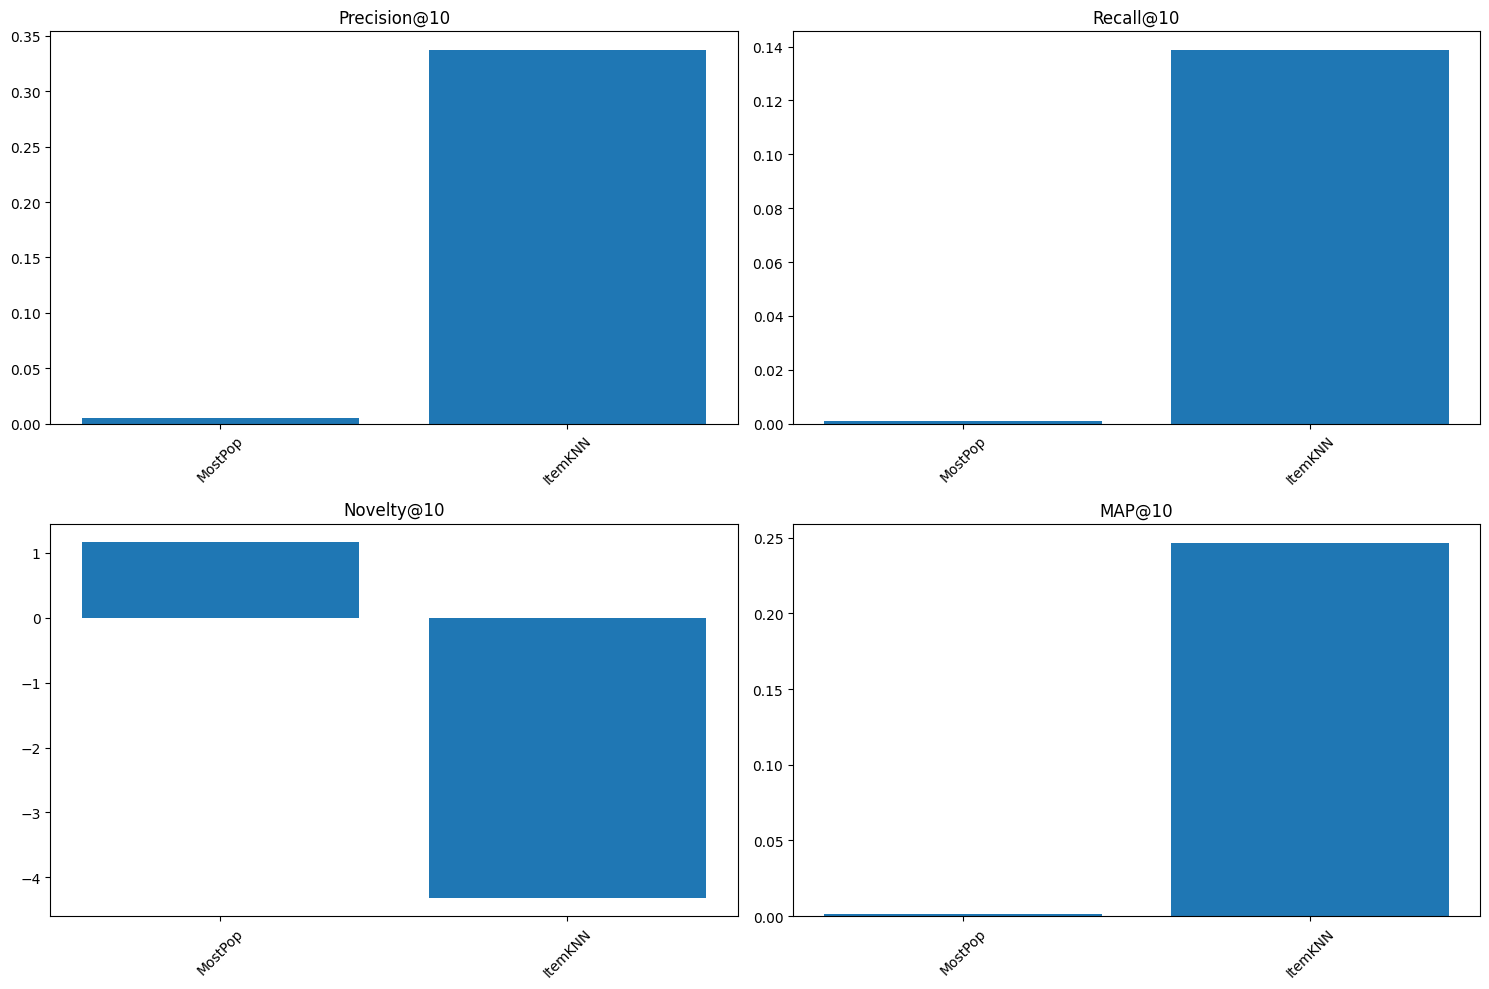

In [38]:
plt.figure(figsize=(15, 10))

metrics = ['Precision@10', 'Recall@10', 'Novelty@10', 'MAP@10']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.bar(results_df.index, results_df[metric])
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()